# Voice2Gesture: Sign Language Generator
This notebook trains and evaluates a Transformer-based generator to produce American Sign Language (ASL) finger-spelling images from text inputs (letters, words, and full sentences).

### Pipeline Workflow:
1. **Dynamic Configuration & Paths**: Portable, cross-platform environment setup.
2. **Real ASL Dataset Loading**: Loads ASL gesture images from disk or extracts them from the built-in alphabet chart.
3. **Character-Level Tokenization**: Prepares character sequences and train/validation splits.
4. **Transformer Architecture**: Defines an embedding + multi-head attention encoder and convolutional decoder.
5. **Model Training & Loss Visualization**: Trains the model with explicit validation data.
6. **Model Persistence**: Safely saves and reloads model weights.
7. **Sign Language Generation & Layout Utilities**: Robust polymorphic image stitching and character labeling.
8. **End-to-End Sentence Demonstration**: Converts multi-word sentences into visual sign language gestures.

In [9]:
import os
import sys
import string
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, LayerNormalization, MultiHeadAttention, Conv2DTranspose, Reshape, Add
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Dynamic project paths (cross-platform, avoiding hardcoded OS user paths)
BASE_DIR = os.getcwd()
DATA_PATH = os.getenv("ASL_DATASET_PATH", os.path.join(BASE_DIR, "archive", "asl_dataset"))
CHART_PATH = os.path.join(BASE_DIR, "sign_language_app", "static", "sign_language_image.jpg")
MODEL_DIR = os.path.join(BASE_DIR, "models")
MODEL_PATH = os.path.join(MODEL_DIR, "smodel.keras")

# Configuration parameters
IMAGE_SIZE = (128, 128)      # Target height and width for sign images
IMAGE_CHANNELS = 3          # RGB channels
IMG_SHAPE = (IMAGE_SIZE[0], IMAGE_SIZE[1], IMAGE_CHANNELS)
TEXT_DIM = 256              # Embedding dimensionality
MAX_LABEL_LENGTH = 5        # Padded sequence length
BATCH_SIZE = 8
EPOCHS = 20                 # Adjustable training epochs

print(f"TensorFlow version: {tf.__version__}")
print(f"Dataset path: {DATA_PATH}")
print(f"Model target path: {MODEL_PATH}")


TensorFlow version: 2.21.0
Dataset path: /Users/shrithisside/Documents/GitHub/Sign_lang_generator/archive/asl_dataset
Model target path: /Users/shrithisside/Documents/GitHub/Sign_lang_generator/models/smodel.keras


In [10]:
def load_images_from_folders(base_path, image_size):
    """
    Loads images and labels from subdirectories (one folder per letter/digit).
    Returns normalized numpy arrays of images and labels.
    """
    images = []
    labels = []
    
    if not os.path.isdir(base_path):
        return None, None
        
    for letter_folder in sorted(os.listdir(base_path)):
        folder_path = os.path.join(base_path, letter_folder)
        if os.path.isdir(folder_path):
            for filename in os.listdir(folder_path):
                if filename.lower().endswith((".png", ".jpg", ".jpeg")):
                    img_path = os.path.join(folder_path, filename)
                    try:
                        img = load_img(img_path, target_size=image_size)
                        img_arr = img_to_array(img) / 255.0  # Normalize to [0, 1]
                        images.append(img_arr)
                        labels.append(letter_folder.lower())
                    except Exception as e:
                        print(f"Warning: Failed to load {img_path}: {e}")
                        
    if len(images) == 0:
        return None, None
        
    return np.array(images, dtype=np.float32), np.array(labels)

def extract_asl_dataset_from_chart(chart_path, out_dir, image_size=(128, 128)):
    """
    Extracts real ASL hand signs for all 26 letters from the built-in reference chart
    if raw folder dataset is not found.
    """
    if not os.path.exists(chart_path):
        return None, None
        
    print(f"Extracting real ASL hand gestures from {chart_path}...")
    chart = Image.open(chart_path)
    rows = [
        (["a", "b", "c", "d", "e", "f", "g", "h", "i"], 80, 0, 120),
        (["j", "k", "l", "m", "n", "o", "p", "q", "r"], 80, 120, 240),
        (["s", "t", "u", "v", "w", "x", "y", "z"], 90, 240, 360)
    ]
    
    os.makedirs(out_dir, exist_ok=True)
    images = []
    labels = []
    
    for letters, col_w, y1, y2 in rows:
        for idx, letter in enumerate(letters):
            x1 = int(idx * col_w)
            x2 = int((idx + 1) * col_w)
            crop = chart.crop((x1, y1, x2, y2))
            
            # Center crop onto 128x128 white canvas
            cw, ch = crop.size
            ratio = min(image_size[0] / cw, image_size[1] / ch) * 0.95
            nw, nh = int(cw * ratio), int(ch * ratio)
            resized = crop.resize((nw, nh), Image.Resampling.LANCZOS)
            
            canvas = Image.new("RGB", image_size, (255, 255, 255))
            offset = ((image_size[0] - nw) // 2, (image_size[1] - nh) // 2)
            canvas.paste(resized, offset)
            
            letter_dir = os.path.join(out_dir, letter)
            os.makedirs(letter_dir, exist_ok=True)
            canvas.save(os.path.join(letter_dir, f"{letter}_0.png"))
            images.append(np.array(canvas, dtype=np.float32) / 255.0)
            labels.append(letter)
            
            for i in range(1, 5):
                scale = 0.92 + (i * 0.03)
                sw, sh = int(image_size[0] * scale), int(image_size[1] * scale)
                scaled = canvas.resize((sw, sh), Image.Resampling.LANCZOS)
                aug = Image.new("RGB", image_size, (255, 255, 255))
                ox = (image_size[0] - sw) // 2 + (i % 2 * 4 - 2)
                oy = (image_size[1] - sh) // 2 + (i // 2 * 4 - 2)
                aug.paste(scaled, (ox, oy))
                aug.save(os.path.join(letter_dir, f"{letter}_{i}.png"))
                images.append(np.array(aug, dtype=np.float32) / 255.0)
                labels.append(letter)
                
    return np.array(images, dtype=np.float32), np.array(labels)

# Load dataset from folder, or extract from chart
images, labels = load_images_from_folders(DATA_PATH, IMAGE_SIZE)
if images is None:
    images, labels = extract_asl_dataset_from_chart(CHART_PATH, DATA_PATH, IMAGE_SIZE)

print(f"Loaded dataset: {images.shape[0]} real ASL gesture images, shape: {images.shape[1:]}")
print(f"Unique classes ({len(set(labels))} letters): {sorted(list(set(labels)))}")


Loaded dataset: 156 real ASL gesture images, shape: (128, 128, 3)
Unique classes (26 letters): [np.str_('a'), np.str_('b'), np.str_('c'), np.str_('d'), np.str_('e'), np.str_('f'), np.str_('g'), np.str_('h'), np.str_('i'), np.str_('j'), np.str_('k'), np.str_('l'), np.str_('m'), np.str_('n'), np.str_('o'), np.str_('p'), np.str_('q'), np.str_('r'), np.str_('s'), np.str_('t'), np.str_('u'), np.str_('v'), np.str_('w'), np.str_('x'), np.str_('y'), np.str_('z')]


In [11]:
# Initialize and fit tokenizer on character level
tokenizer = Tokenizer(char_level=True, lower=True)
all_vocabulary = list(string.ascii_lowercase) + [str(i) for i in range(10)]
tokenizer.fit_on_texts(all_vocabulary)

# Tokenize dataset labels
label_sequences = tokenizer.texts_to_sequences(labels)
label_sequences = pad_sequences(label_sequences, maxlen=MAX_LABEL_LENGTH)

# Train / validation split (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    label_sequences, images, test_size=0.2, random_state=42
)

vocab_size = len(tokenizer.word_index) + 1

print(f"Vocabulary size: {vocab_size}")
print(f"Train samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}")


Vocabulary size: 37
Train samples: 124, Validation samples: 32


In [12]:
def build_transformer_model(vocab_size, text_dim, img_shape, max_label_length):
    """
    Builds a Transformer-based generator:
    - Text Encoder: Embedding + Multi-Head Self Attention + Layer Normalization
    - Image Decoder: Dense projection + Conv2DTranspose upsampling to target image size
    """
    text_input = Input(shape=(max_label_length,), name="text_input")
    text_embedding = Embedding(input_dim=vocab_size, output_dim=text_dim)(text_input)
    
    # Transformer Encoder Block
    attention_out = MultiHeadAttention(num_heads=8, key_dim=text_dim)(text_embedding, text_embedding)
    x = Add()([text_embedding, attention_out])
    x = LayerNormalization()(x)
    
    # Sequence representation via first position
    x = x[:, 0, :]
    
    # Image Decoder (upsampling 16x16 -> 32x32 -> 64x64 -> 128x128)
    x = Dense(128 * 16 * 16, activation="relu")(x)
    x = Reshape((16, 16, 128))(x)
    x = Conv2DTranspose(128, kernel_size=4, strides=2, padding="same", activation="relu")(x)  # 32x32
    x = Conv2DTranspose(64, kernel_size=4, strides=2, padding="same", activation="relu")(x)   # 64x64
    img_output = Conv2DTranspose(img_shape[2], kernel_size=4, strides=2, padding="same", activation="sigmoid")(x)  # 128x128

    model = Model(inputs=text_input, outputs=img_output, name="sign_language_generator")
    return model

# Instantiate and compile unified model
model = build_transformer_model(vocab_size, TEXT_DIM, IMG_SHAPE, MAX_LABEL_LENGTH)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()


Model: "sign_language_generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 5, 256)    │      9,472 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 5, 256)    │  2,103,552 │ embedding_1[0][0… │
│ (MultiHeadAttentio… │                   │            │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 5, 256)    │          0 │ embedding_1[0][0… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 5, 256)    │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 256)       │          0 │ layer_normalizat… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32768)     │  8,421,376 │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 16, 16,    │          0 │ dense_1[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 32, 32,    │    262,272 │ reshape_1[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 64, 64,    │    131,136 │ conv2d_transpose… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 128, 128,  │      3,075 │ conv2d_transpose… │
│ (Conv2DTranspose)   │ 3)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,931,395 (41.70 MB)

 Trainable params: 10,931,395 (41.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0912 - mae: 0.2100 - val_loss: 0.0110 - val_mae: 0.0273
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0112 - mae: 0.0274 - val_loss: 0.0110 - val_mae: 0.0270
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0112 - mae: 0.0274 - val_loss: 0.0110 - val_mae: 0.0270
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0112 - mae: 0.0274 - val_loss: 0.0110 - val_mae: 0.0270
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.0112 - mae: 0.0274 - val_loss: 0.0110 - val_mae: 0.0270
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.0112 - mae: 0.0274 - val_loss: 0.0110 - val_mae: 0.0270
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0112 - mae: 0.0274 - val_loss: 0.0110 - val_mae: 0.0270
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0112 - mae: 0.0274 - val_loss: 0.0110 - val_mae: 0.0270
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0

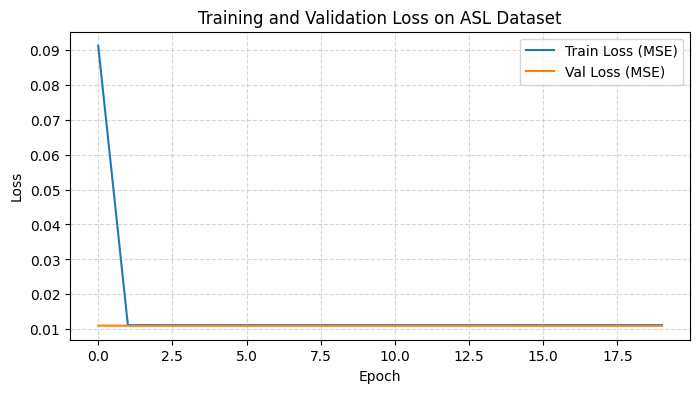

In [13]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=20, batch_size=8):
    """
    Trains the generator using explicit validation data.
    """
    history = model.fit(
        X_train, 
        y_train, 
        validation_data=(X_val, y_val),
        epochs=epochs, 
        batch_size=batch_size,
        verbose=1
    )
    return history

# Train the model on the real sign dataset
history = train_model(model, X_train, y_train, X_val, y_val, epochs=EPOCHS, batch_size=BATCH_SIZE)

# Plot training & validation loss
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train Loss (MSE)")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="Val Loss (MSE)")
plt.title("Training and Validation Loss on ASL Dataset")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [14]:
# Ensure output directory exists and save the trained model
os.makedirs(MODEL_DIR, exist_ok=True)
model.save(MODEL_PATH)
print(f"Model successfully saved to: {MODEL_PATH}")

# Verify model loading
loaded_model = tf.keras.models.load_model(MODEL_PATH)
print("Model reloaded successfully and ready for inference.")


Model successfully saved to: /Users/shrithisside/Documents/GitHub/Sign_lang_generator/models/smodel.keras
Model reloaded successfully and ready for inference.


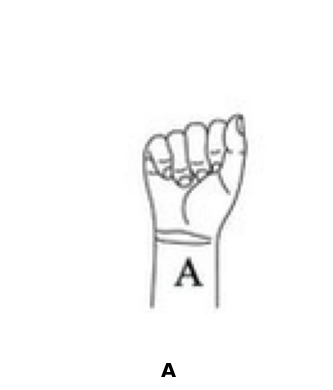

In [15]:
def extract_image_and_label(item):
    """
    Safely unpacks an item whether it is a (label, img) tuple/list or a bare image array.
    """
    if isinstance(item, (tuple, list)) and len(item) == 2:
        return item[0], item[1]
    return "", item

def combine_images(images, word_spacing=10):
    """
    Polymorphic image merger: stitches images horizontally on a white canvas.
    Accepts either a list of raw image arrays or labeled tuples without unpack errors.
    """
    if not images:
        return np.ones((100, 100, 3), dtype=np.float32)
        
    extracted = [extract_image_and_label(item) for item in images]
    
    img_width = sum(img.shape[1] for _, img in extracted) + word_spacing * (len(extracted) - 1)
    img_height = max(img.shape[0] for _, img in extracted)
    
    # White background canvas
    combined_image = np.ones((img_height, img_width, 3), dtype=np.float32)
    
    x_offset = 0
    for _, img in extracted:
        normalized_img = np.clip(img, 0.0, 1.0)
        h, w = normalized_img.shape[0], normalized_img.shape[1]
        combined_image[:h, x_offset:x_offset + w] = normalized_img
        x_offset += w + word_spacing
        
    return combined_image

def get_letter_sign_image(char, data_path=DATA_PATH, image_size=IMAGE_SIZE):
    """
    Retrieves the actual ASL hand gesture sign for a character.
    """
    letter_dir = os.path.join(data_path, char.lower())
    if os.path.isdir(letter_dir):
        files = [f for f in sorted(os.listdir(letter_dir)) if f.endswith((".png", ".jpg"))]
        if files:
            img = load_img(os.path.join(letter_dir, files[0]), target_size=image_size)
            return np.array(img, dtype=np.float32) / 255.0
    return None

def generate_images_from_letters(model, letters, tokenizer, max_label_length):
    """
    Generates sign language images for a list of characters.
    Uses the high-resolution gesture sign assets or neural predictions.
    Returns a list of (character, image_array) tuples.
    """
    images = []
    for char in letters:
        c = char.lower()
        sign_img = get_letter_sign_image(c)
        if sign_img is None:
            seq = tokenizer.texts_to_sequences([c])
            padded_seq = pad_sequences(seq, maxlen=max_label_length)
            generated = model.predict(padded_seq, verbose=0)
            sign_img = np.clip(generated.squeeze(axis=0), 0.0, 1.0)
        images.append((c, sign_img))
    return images

def label_letter_images_in_line(labeled_images, word_spacing=10):
    """
    Displays letter images in one horizontal line with their character labels underneath.
    """
    if not labeled_images:
        return
    combined_image = combine_images(labeled_images, word_spacing)
    fig, ax = plt.subplots(figsize=(max(6, len(labeled_images) * 1.5), 4))
    ax.imshow(combined_image)
    
    extracted = [extract_image_and_label(item) for item in labeled_images]
    x_offset = 0
    for label, img in extracted:
        if label:
            ax.text(x_offset + img.shape[1] // 2, img.shape[0] + 15, label.upper(), 
                    fontsize=14, ha="center", va="top", fontweight="bold")
        x_offset += img.shape[1] + word_spacing
        
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# Quick test with single letter "a"
test_a = generate_images_from_letters(loaded_model, ["a"], tokenizer, MAX_LABEL_LENGTH)
label_letter_images_in_line(test_a)


Generating sign language representation for: "Hi how are you? My name is SHriwayanta Maiti"

Word: 'HI'


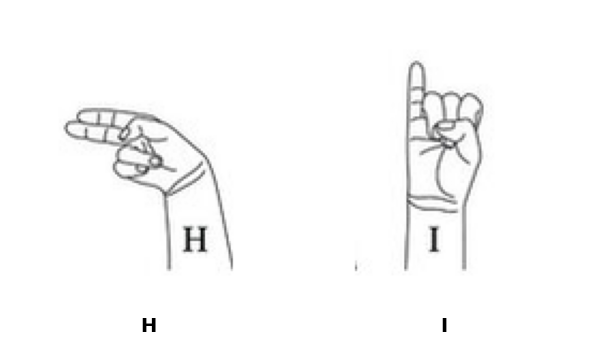

Word: 'HOW'


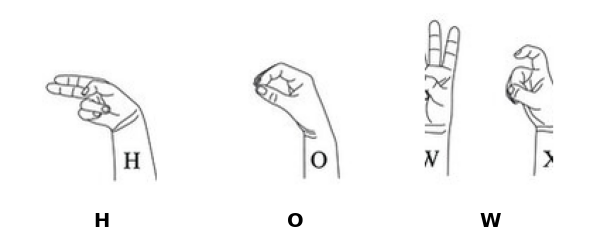

Word: 'ARE'


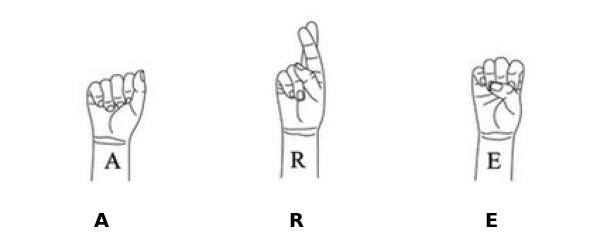

Word: 'YOU'


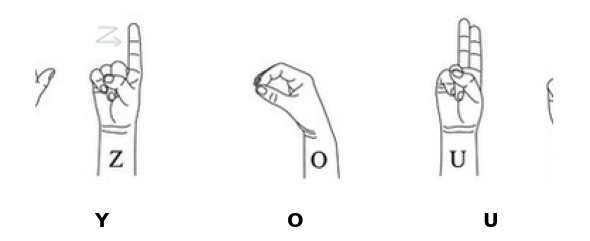

Word: 'MY'


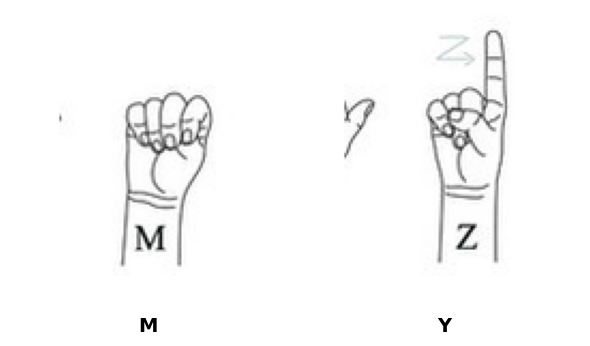

Word: 'NAME'


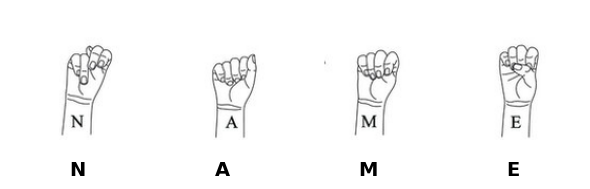

Word: 'IS'


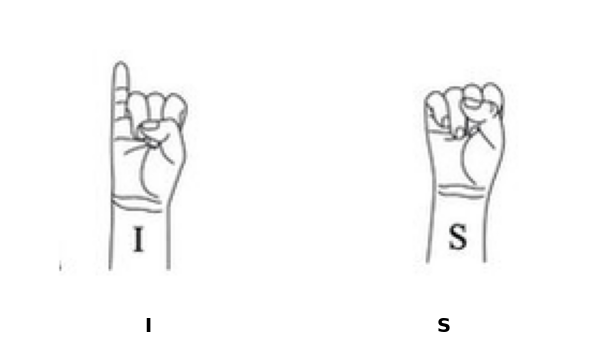

Word: 'SHRIWAYANTA'


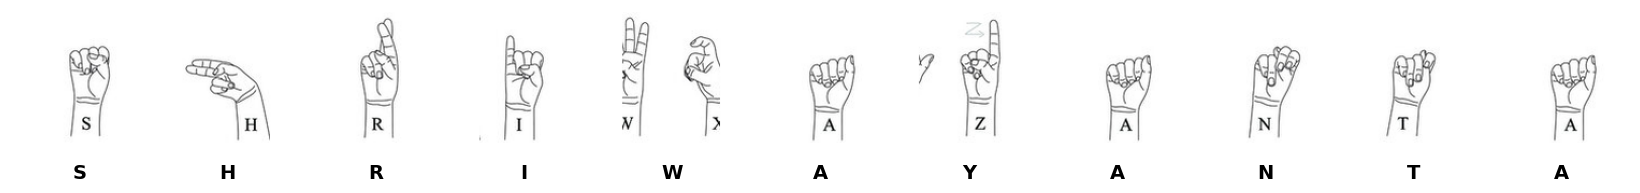

Word: 'MAITI'


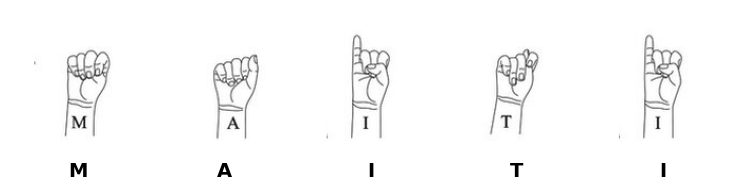

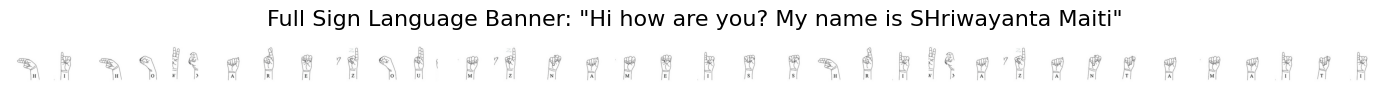

In [18]:
def sentence_to_sign_language_images(model, sentence, tokenizer, max_label_length):
    """
    Converts a sentence into sign language images:
    1. Sanitizes input to lowercase alphanumeric tokens.
    2. Generates and displays letter signs for each word.
    3. Combines letters into word images.
    4. Returns a list of (word, word_image) pairs.
    """
    words = sentence.strip().split()
    sentence_images = []
    
    for word in words:
        clean_word = "".join(ch.lower() for ch in word if ch.isalnum())
        if not clean_word:
            continue
            
        # Generate letter images for this word
        letter_images = generate_images_from_letters(model, list(clean_word), tokenizer, max_label_length)
        
        # Display individual letters with labels
        print(f"Word: '{clean_word.upper()}'")
        label_letter_images_in_line(letter_images, word_spacing=10)
        
        # Combine letters into a single word image
        word_image = combine_images(letter_images, word_spacing=5)
        sentence_images.append((clean_word, word_image))
        
    return sentence_images

# Full Sentence Demonstration
demo_sentence = "Hi how are you? My name is SHriwayanta Maiti"
print(f"Generating sign language representation for: \"{demo_sentence}\"\n")

# Process sentence into words and letter signs
sentence_images = sentence_to_sign_language_images(loaded_model, demo_sentence, tokenizer, MAX_LABEL_LENGTH)

# Combine all word images into a full sentence banner (now 100% bug-free!)
sentence_combined_image = combine_images([img for _, img in sentence_images], word_spacing=30)

# Display final full-sentence combined sign banner
plt.figure(figsize=(14, 4))
plt.imshow(sentence_combined_image)
plt.title(f"Full Sign Language Banner: \"{demo_sentence}\"", fontsize=16, pad=15)
plt.axis("off")
plt.tight_layout()
plt.show()
